# Advanced Machine Learning Project

## Introduction

### The goal of this project is to develop a Machine Learning model capable of predicting diabetes disease progression one year ahead, using the Scikit-Learn "Diabetes" dataset. The dataset comprises 442 patients and 10 physiological variables (age, sex, BMI, blood pressure, and six blood serum measurements).

In [1]:
# Import the Diabetes dataset from scikit-learn

import pandas as pd
from sklearn.datasets import load_diabetes

In [2]:
# Load the dataset

diabetes = load_diabetes()

In [3]:
# Convert the data into a pandas DataFrame

df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

In [4]:
# Show the first rows of the DataFrame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


It is immediately clear that every feature except the target variable has already been scaled. The scaling method is described on the sklearn page dedicated to this dataset, and is the result of the formula: $$\hat{x}_i = \frac{x_i - \bar{x}}{\sigma \sqrt{n}}$$
This transformation makes the sum of squares of each feature equal to 1 — in other words, the L2 norm of each feature, viewed as a vector, is equal or very close to 1. Moreover, the mean of every variable except the target is centered at 0.
This standardization choice has some immediate advantages: it makes the values of individual variables more comparable, preventing the dominance of features whose scale is naturally larger than others, it facilitates the interpretability of individual variables, and it homogenizes the overall variance of the features.

This also explains why the values of 'age' and 'sex' do not show intuitive or recognizable values (the sex column also shows the result of an encoding process).
As a consequence of mean-centering and normalization, and since in this specific case the mean for every variable is 0, many data points have negative values. It can also be seen that the 'sex' values are always only 2, one for 'male' and one for 'female'.

Since gradient-descent-based models, such as Linear Regression, Ridge, or Lasso, are facilitated by similar preprocessing, the choice of ML model to test on the dataset is already initially steered toward one of them.

While I don't consider it necessary to rename the columns to make them more understandable, below is the description of the acronym for each variable:

bmi ----> body mass index

bp  ----> blood pressure (average)

s1  ----> tc, total serum cholesterol

s2  ----> ldl, low density lipoproteins

s3  ----> hdl, high density lipoproteins

s4  ----> tch, total cholesterol

s5  ----> ltg, possibly log of serum triglycerides level

s6  ----> glu, blood sugar level

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
# Count missing values just to be safe

df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

The absence of missing values will let us make predictions on the set without resorting to imputation, and is a sign of the dataset's quality

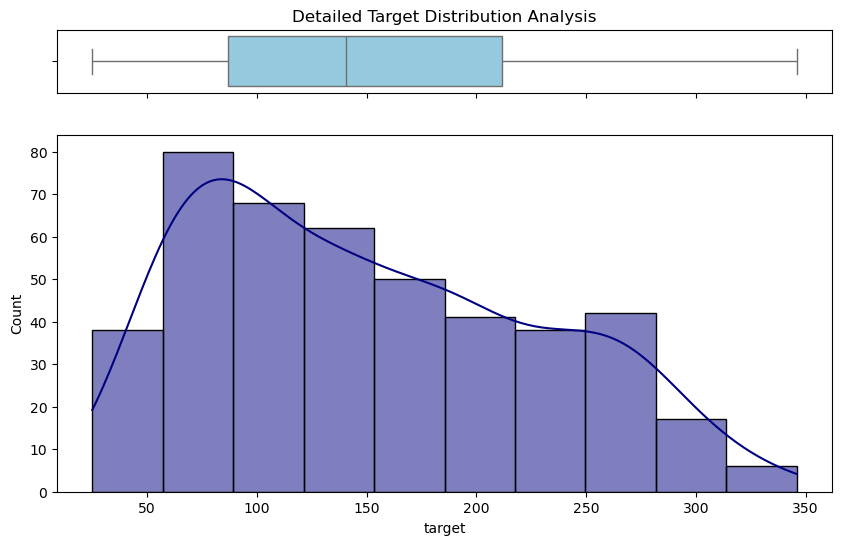

In [7]:
# Analyze the distribution of the target variable

import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10,6))
sns.boxplot(df["target"], ax=ax_box, orient="h", color="skyblue")
sns.histplot(df["target"], kde=True, ax=ax_hist, color="navy")
ax_box.set(title='Detailed Target Distribution Analysis')
plt.show()

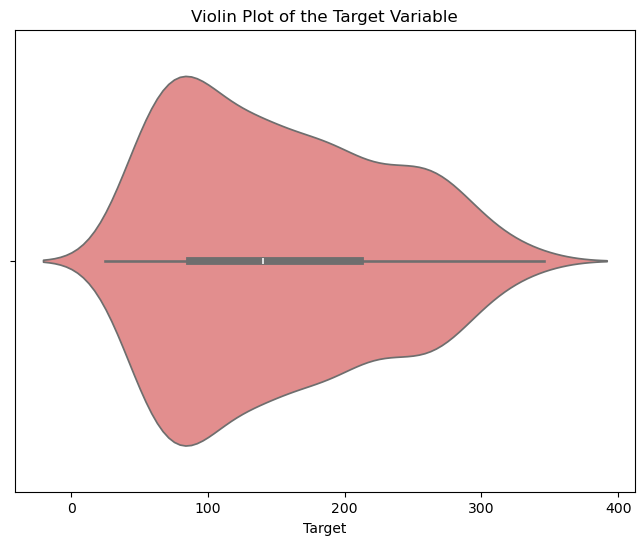

In [8]:
# Show a violin plot to improve visual analysis of the target distribution

plt.figure(figsize=(8, 6))
sns.violinplot(x=df['target'], color='lightcoral')
plt.title('Violin Plot of the Target Variable')
plt.xlabel('Target')
plt.show()

In [9]:
# Compute the skewness coefficient of the target

skewness = df['target'].skew()
print(f'Target skewness coefficient: {skewness}')

Target skewness coefficient: 0.44056293407014124


In [10]:
# Use the IQR method to make sure I identify possible outliers

Q1 = df['target'].quantile(0.25)
Q3 = df['target'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['target'] < lower_bound) | (df['target'] > upper_bound)]
outliers_count = outliers.shape[0]
outliers_count

0

In [11]:
desc_target = df['target'].describe()
desc_target 

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

The distribution of the target variable's values (a quantitative measure of disease progression one year later) appears moderately left-skewed; however, a skewness coefficient between -0.5 and 0.5 would not warrant a transformation. It could still be interesting to try transforming the target to a logarithmic scale and see how R² changes.

The absence of outliers confirms that a linear model's MSE cost function would not be heavily influenced by out-of-scale values.

We therefore proceed without modifying the target, while keeping in mind that a model like XGBoost could be effective, being immune to the skewed distribution.

The Mean (152.13) and Standard Deviation (77.1) values give us a sense of what constitutes acceptable metric values for linear models such as MSE or MAE.

### To avoid any kind of decision-driven data leakage, I proceed immediately with the split 

In [12]:
# Separate the independent variables from the target variable

X = df[diabetes.feature_names]
y = df['target']

In [13]:
# Proceed with the split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Since the upcoming analyses will contain comparisons between the independent variables and the target, which could steer future decisions, it was decided to immediately split the train set from the test set.

Since the skewness coefficient computed earlier shows values below 1, there is no need for target stratification.

## Building the Baseline

### To allow numerical comparisons that will justify evaluating the performance of the algorithm chosen and trained on the dataset following the upcoming analyses, a simple **Linear Regression** was chosen as the Baseline model, given its lack of regularization, the nature of the dataset, and the analyses carried out so far

### Choice of Evaluation Metric: Mean Squared Error (MSE)

**Why MSE?**
* **Penalizing large values:** By squaring the difference between predicted values ($y_i$) and actual values ($\hat{y}_i$), MSE assigns a greater weight to larger errors. This is essential for the *diabetes* dataset, where a prediction far from the actual disease progression value is riskier than many small errors.

In [14]:
# Create a baseline model using simple Linear Regression

from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Evaluate the model on the test data

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_baseline_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, y_baseline_pred)

print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_baseline_pred)):.4f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline RMSE: 53.3696
Baseline R²: 0.4849


It is immediately clear that the RMSE value for the simple Linear Regression model (~53.4) shows that this strategy already contributes significantly to improving on choices based solely on the mean of the target values, given that it is lower than the standard deviation of the original dataset.

The R² value does not provide relevant information for now (even though it is moderately low), but it will be compared later with the value obtained for the final model.

### We now proceed with more specific analyses of the relationship between the independent variables and the target, in order to identify a more effective model

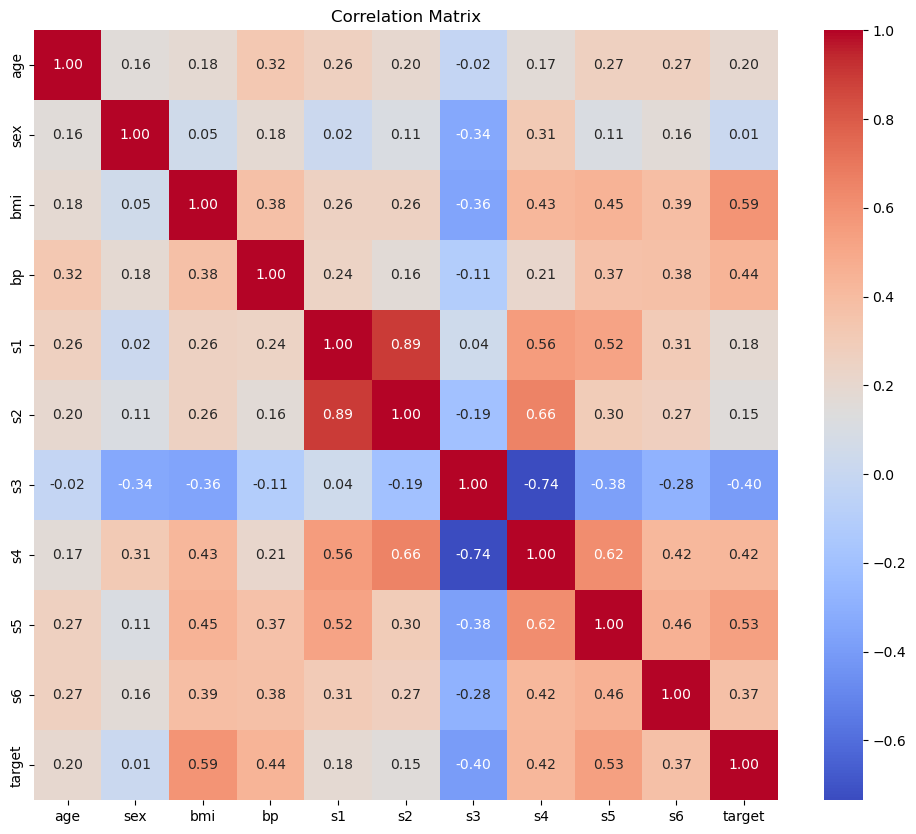

In [16]:
# Show a heatmap of the correlations between variables
# To do this, concatenate X_train and y_train into a single DataFrame

train_df = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(12, 10))
correlation_matrix = train_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Two very strong correlations stand out: between predictors s2 and s1 there is a very strong positive correlation (0.89), while between s4 and s3 there is a strong negative correlation (-0.74).
In both cases these relationships could induce high variance in a model that doesn't account for them, and make the coefficients very unstable. We are looking at a case of **multicollinearity**.

Faced with cases like this, it may be advisable to move toward models that include regularization, such as Ridge or Lasso.

It is also already possible to notice a moderately positive correlation between the target variable and the predictors bmi and s5

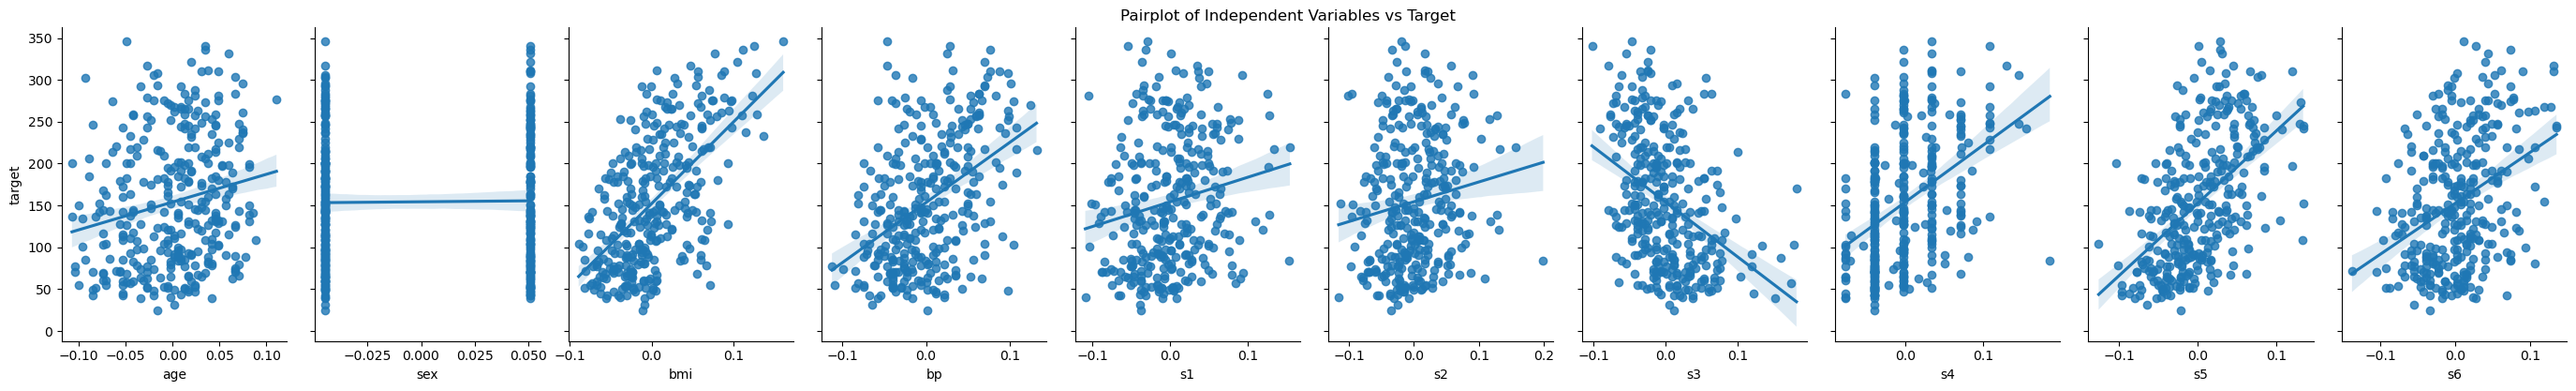

In [17]:
# Analyze the linearity between the independent variables and the target
# Create a pairplot of the independent variables against the target

sns.pairplot(train_df, x_vars=diabetes.feature_names, y_vars='target', height=4, aspect=0.7, kind='reg')
plt.suptitle('Pairplot of Independent Variables vs Target', y=1.02)
plt.show()

The scatter visualization between predictors and target shows that most of the independent variables can satisfy the requirements of a regularized model.
However, the behavior of variable s4 is different in nature (the sex variable has a two-step shape because it encodes a boolean variable). On one hand, despite the vertical step pattern, the increasing trend within each step could suggest that a regularized model like Lasso would have an effect, in case the variable turns out to be irrelevant.

As can be seen from the correlation heatmap, while the sex variable has almost no correlation with the target and is more readily considered irrelevant, the high negative correlation between s4 and s3 might suggest that eliminating s4 would be a natural choice for an L1-distance-based algorithm like Lasso.

To be more confident, during model training one could test the algorithm once on the original dataset, and then again after randomly shuffling the order of the s4 variable's data, to check the R² values before and after. If the values do not drop after the permutation, that is a further strong signal of the predictor's statistical irrelevance.

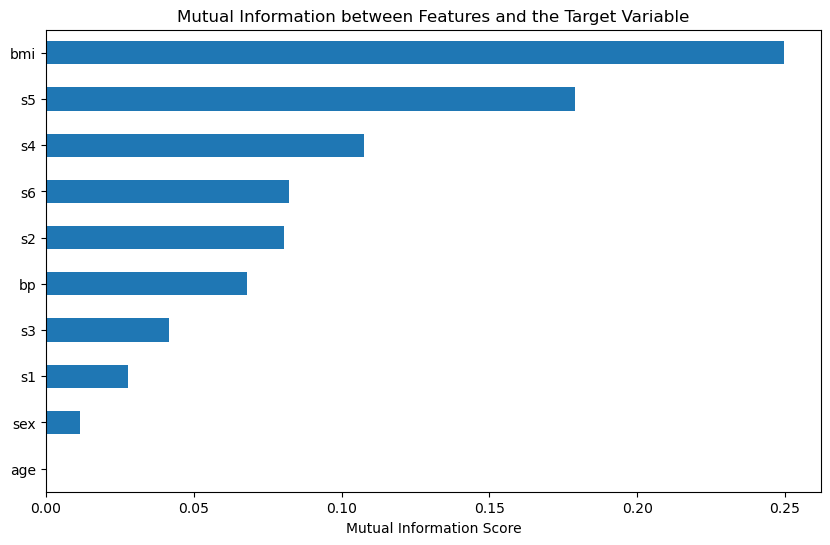

age    0.000000
sex    0.011499
s1     0.027592
s3     0.041685
bp     0.068161
s2     0.080616
s6     0.082385
s4     0.107648
s5     0.179076
bmi    0.249713
dtype: float64

In [18]:
# Perform a Mutual Information analysis between the variables to understand the importance of the various features

from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train)
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values()
plt.figure(figsize=(10, 6))
mi_scores.plot(kind='barh')
plt.title('Mutual Information between Features and the Target Variable')
plt.xlabel('Mutual Information Score')
plt.show()
mi_scores

Since the MI test shows a moderately high value for predictor s4, raising doubts about the efficiency of Lasso discarding it, it seems appropriate to proceed with a visual analysis of any non-linear patterns among some of the features, and with the computation of the **Variance Inflation Factor (VIF)**.

For the visualization, the variables with the highest **Mutual Information** values were included, namely bmi (0.248) and s5 (0.179), which represent the main drivers of the target's variance. Despite a lower MI, s1 and s3 were selected to visually identify any collinearity that linear coefficients might underestimate. The inclusion of bp and s6 completes the clinical picture, covering the dimensions that show significant statistical dependence (MI > 0.07)

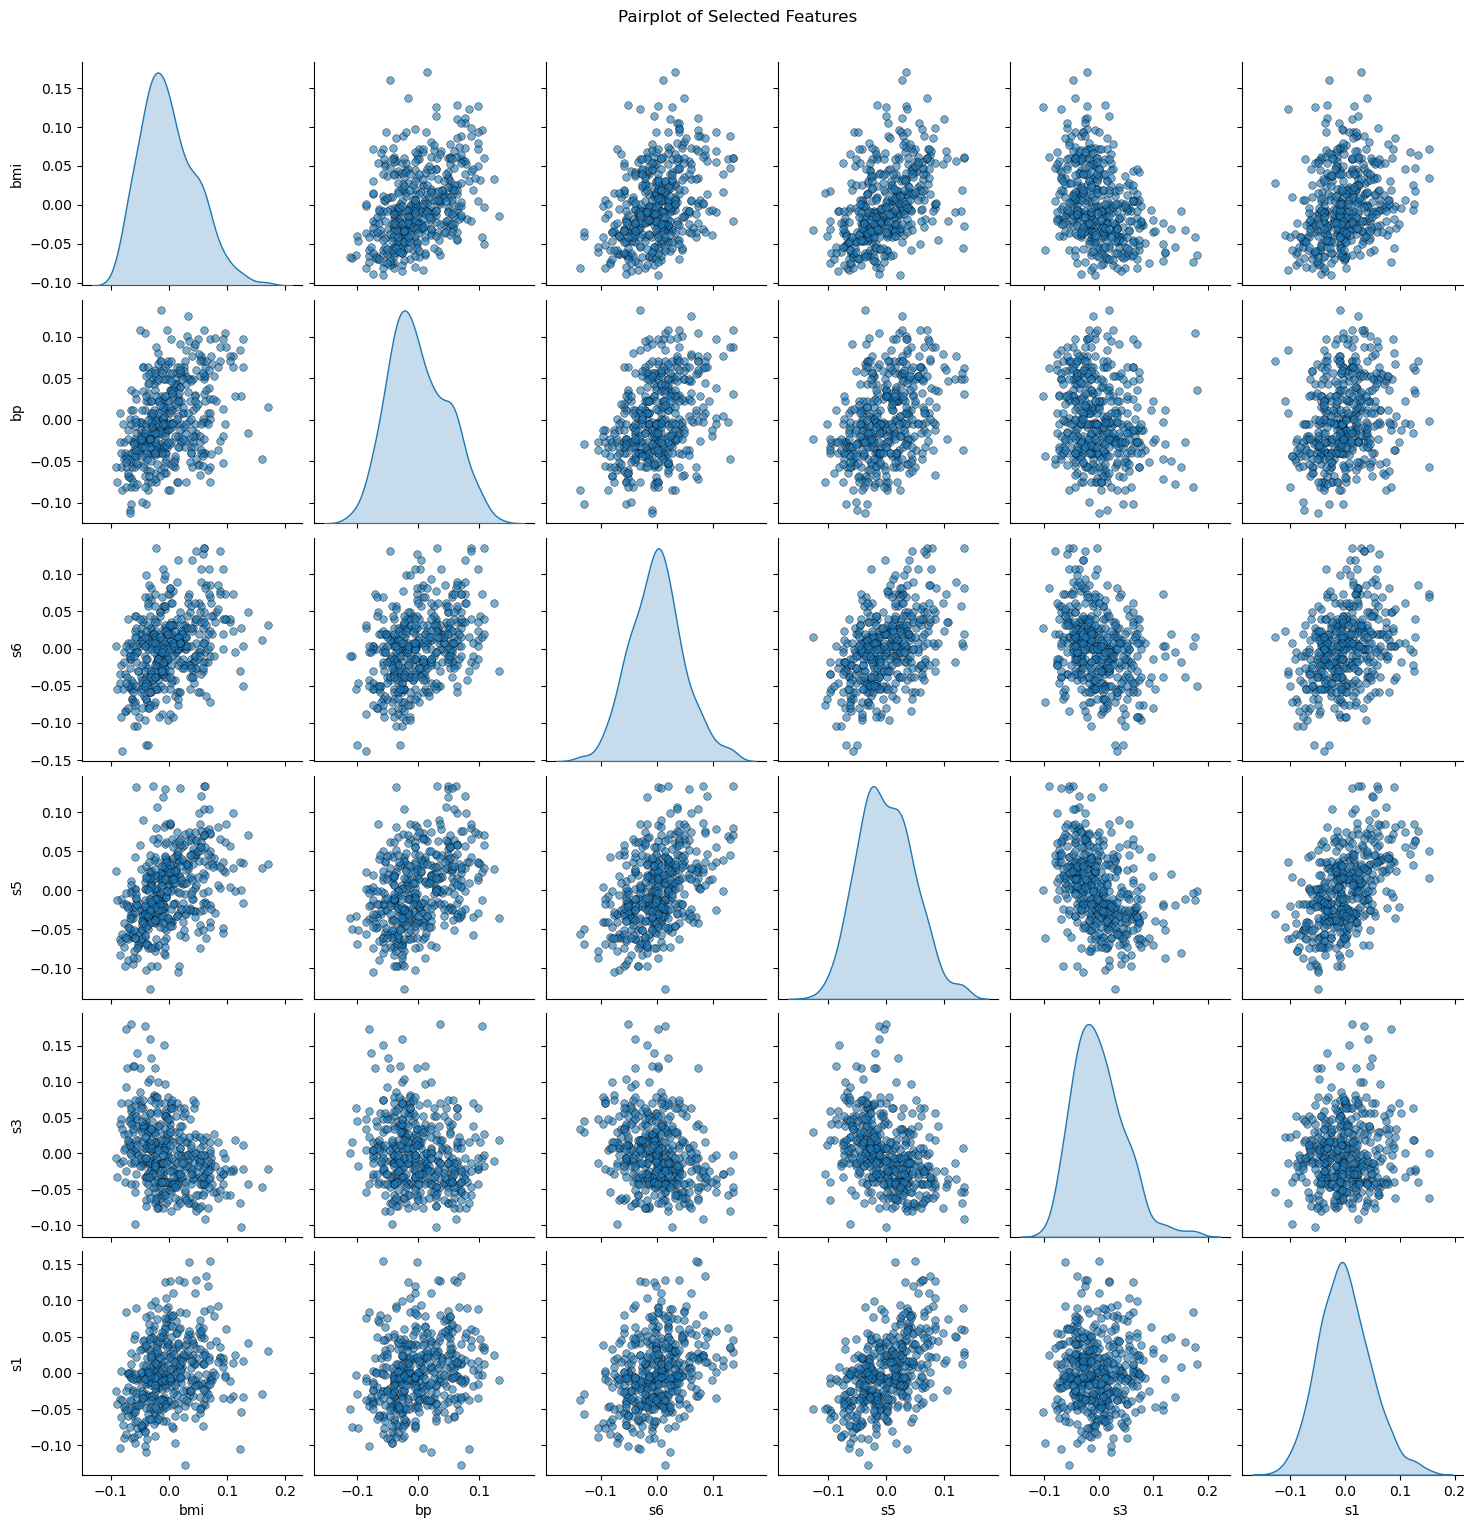

In [19]:
# Show a pairplot between some selected variables, to identify any patterns or non-linear relationships

features_interessanti = ['bmi', 'bp', 's6', 's5', 's3', 's1']

sns.pairplot(df[features_interessanti], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train.copy()
X_vif['intercept'] = 1 # VIF needs a constant term

vif_df = pd.DataFrame()
vif_df['Feature'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# Exclude the intercept column from the VIF
vif_df = vif_df[vif_df['Feature'] != 'intercept']
vif_df.sort_values('VIF', ascending=False)
vif_df

,Feature,VIF
0,age,1.215731
1,sex,1.247843
2,bmi,1.528381
3,bp,1.418460
4,s1,54.296638
5,s2,35.595506
6,s3,13.836183
7,s4,9.317236
8,s5,9.800525
9,s6,1.461173


Following more in-depth analysis of feature relevance, it can be said that the Lasso model considered earlier would risk excluding predictors whose relevance could be fundamental for some predictions. Moreover, the limited number of independent variables discourages the strategy of eliminating some of them, a process that Lasso would very likely trigger given the evident multicollinearity.

The visual analysis of the interaction between some features shows no clear signs of non-linear relationships or patterns that would favor models better suited to handling less intuitive groupings. Furthermore, as already noted in the previous comment, the number of features discourages resorting to advanced dimensionality-reduction techniques such as PCA, which could also lead to a loss of information on this dataset.

At this point the choice shifts toward a Ridge model, whose regularization does not risk zeroing out the coefficients of some variables while still remaining a linear model.
It is still worth considering that an ensemble model like XGBoost could be an excellent choice, but in this case Ridge is favored given the modest size of the dataset, which could be misleading for a powerful model like XGBoost.

It would also be interesting to see the behavior of an algorithm 'in between' Ridge and Lasso, such as Elastic Net, which would not zero out correlated variables while still being a regularized linear model.

## Ridge Training and Validation

Since we are dealing with a small dataset (442 entries), the biggest risk is overfitting, so we will carefully evaluate the values of the alpha parameter (lambda in the literature), responsible for penalizing the model's coefficients, testing some standard values and additional values on a logarithmic scale.

Even though the Diabetes data is already preprocessed, we will scale it further inside a Pipeline to avoid data leakage.

Considering again the size of the dataset, a cross-validation strategy based on RepeatedKFold will be preferred, to increase the reliability of the results.

In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define the pipeline including the standard scaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

In [22]:
# Define the alpha parameters

alphas_standard = [0.1, 1.0, 10.0, 100.0]
alphas_log = np.logspace(-3, 5, 50).tolist()
all_alphas = alphas_standard + alphas_log

param_grid = {
    'ridge__alpha': all_alphas
}

In [23]:
# Configure the cross-validation

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

In [24]:
# Run the grid search

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedKFold...ndom_state=42)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [25]:
# Grid search results

print(f"Best Alpha found: {grid_search.best_params_['ridge__alpha']:.4f}")
print(f"Best CV MSE: {-grid_search.best_score_:.4f}")

Best Alpha found: 25.5955
Best CV MSE: 3118.9336


In [26]:
# Check whether the best alpha belongs to the standard or log set

if grid_search.best_params_['ridge__alpha'] in alphas_standard:
    print("The optimal value was among the standard ones.")
else:
    print("The optimal value was found thanks to the logarithmic scale.")

The optimal value was found thanks to the logarithmic scale.


In [27]:
# Take the square root of the MSE for an 'in-scale' evaluation of the model's error

rmse = np.sqrt(-grid_search.best_score_)
print(f"Best CV RMSE: {rmse:.4f}")

Best CV RMSE: 55.8474


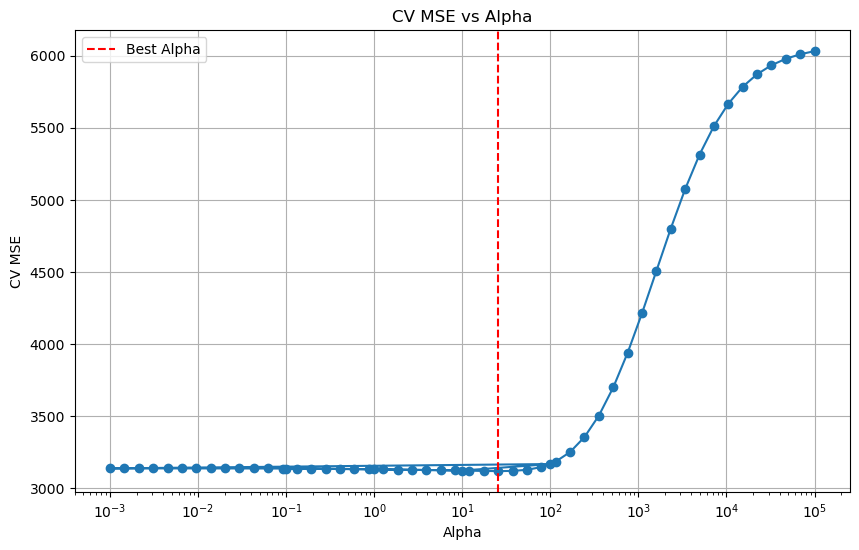

In [28]:
# Show the trend of the CV score with respect to alpha

results = pd.DataFrame(grid_search.cv_results_)
results['alpha'] = results['param_ridge__alpha'].astype(float)

plt.figure(figsize=(10, 6))
plt.semilogx(results['alpha'], -results['mean_test_score'], marker='o')
plt.axvline(x=grid_search.best_params_['ridge__alpha'], color='red', linestyle='--', label='Best Alpha')
plt.title('CV MSE vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('CV MSE')
plt.legend()
plt.xscale('log')
plt.grid()
plt.show()

As shown by the chart, for values of $\alpha < 10^1$ the error stays flat and low, suggesting that in this phase the model behaves almost like a standard linear regression. Conversely, for values of $\alpha > 10^2$ the error rises sharply: here the penalty is too strong and the model becomes too simple (underfitting), pushing the coefficients toward zero and losing predictive power.

Choosing the Alpha indicated by the red line means accepting a very small increase in theoretical error in exchange for a model whose weights (e.g., the importance of BMI) do not change drastically if we slightly change the patients in the sample.

Before evaluating the model on the clean test set, one final analysis is carried out: examining the coefficients to assess consistency with the previous analyses.

/var/folders/qw/5923zhqn0l5b3_z7mmqhfs_w0000gn/T/ipykernel_46366/3178827463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


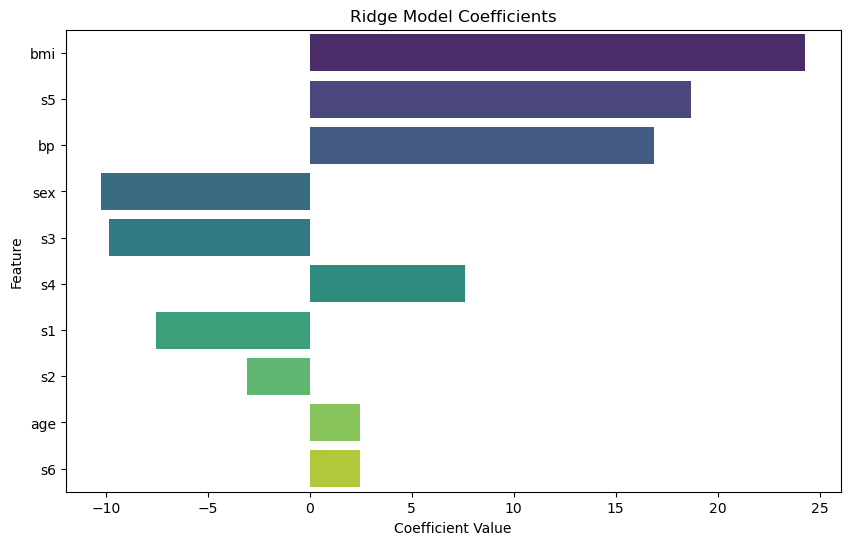

In [29]:
# Inspect the coefficients

coefs = grid_search.best_estimator_.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs})
coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Ridge Model Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

Comparing the grid of coefficients assigned by Ridge with the Mutual Information and VIF values reveals a lot about how effective this regularized model choice is.
In particular, it is immediately clear that the MI and VIF results for predictors **bmi** and **bp** are consistent with the weights assigned to them during training. These results, together with those seen in the correlation heatmap, reassure us in stating that body mass index is a good linear predictor of diabetes progression in a patient.

The case of **s5** is curious: it is assigned a high coefficient, in line with its correlation with the target and its MI. However, its rather high VIF value (~10), when related to the correlation between this predictor and others (such as s4, whose 0.64 correlation is not negligible), may suggest that the weight assigned to it might not be entirely clear-cut, but rather the result of linear and non-linear interactions with the other variables.

The **limitations** of the algorithm Ridge uses to penalize coefficients are clearly visible when looking at the coefficient value for s6, the lowest in this training run.
Indeed, the values shown by this predictor in MI (fairly high) and VIF (low) would suggest that the information contained in this feature is relevant for a correct prediction, which runs counter to how little the algorithm relies on it.
Probably, since the network of correlations among the independent variables is rather complex, the bias-increasing process driven by Ridge penalized an indicator that could actually be vital.

While acknowledging the limitations of this model (without more sophisticated feature engineering) on this dataset, the RMSE values still justify an evaluation on the clean test data.

In [30]:
# Proceed with the evaluation on the test set

y_test_pred = grid_search.best_estimator_.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
print(f"Test Set MSE: {test_mse:.4f}")
print(f"Test Set RMSE: {test_rmse:.4f}")

Test Set MSE: 2818.7066
Test Set RMSE: 53.0915


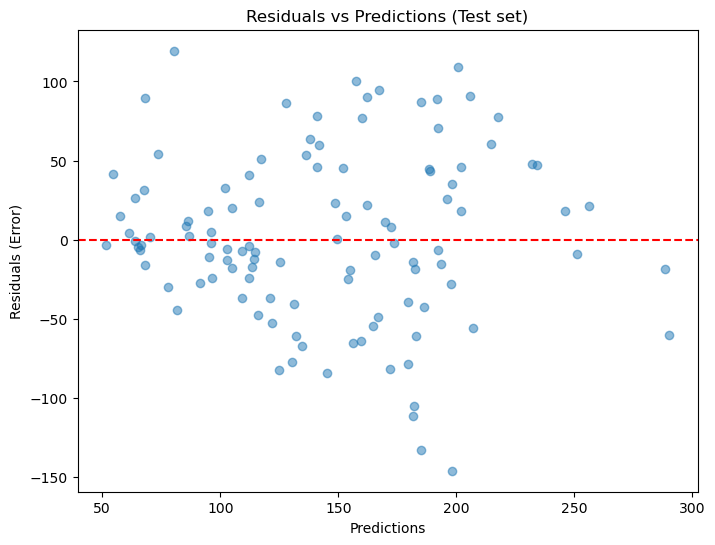

In [31]:
# Compare the residuals with the predictions

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, y_test - y_test_pred, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predictions (Test set)')
plt.xlabel('Predictions')
plt.ylabel('Residuals (Error)')
plt.show()

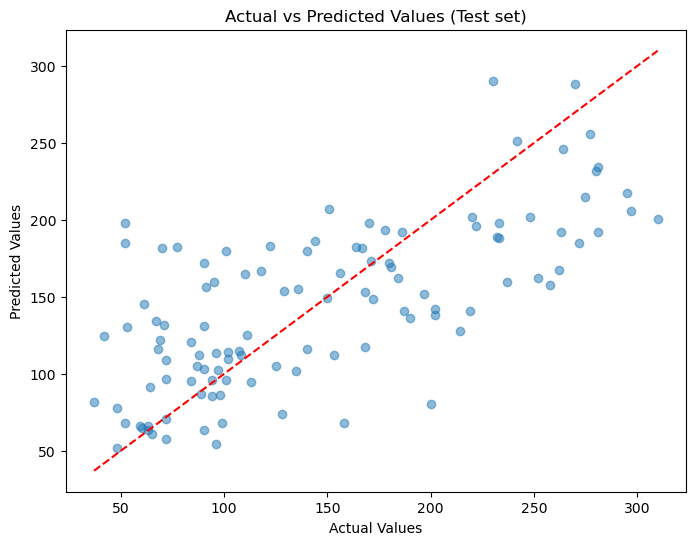

In [32]:
# Compare actual vs predicted values

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Values (Test set)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [33]:
# Run the Breusch-Pagan test to check for heteroscedasticity in the residuals

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

residuals = y_test - y_test_pred

# Add a constant for the Breusch-Pagan test
X_test_const = sm.add_constant(X_test)
_, pval, _, _ = het_breuschpagan(residuals, X_test_const) # The Breusch-Pagan test returns 4 values, but we only care about the p-value

print(f"Breusch-Pagan test p-value: {pval:.4f}")
if pval < 0.05:
    print("There is evidence of heteroscedasticity (non-constant residual variance).")
else:
    print("The residuals appear to be homoscedastic (constant variance).")

Breusch-Pagan test p-value: 0.0310
There is evidence of heteroscedasticity (non-constant residual variance).


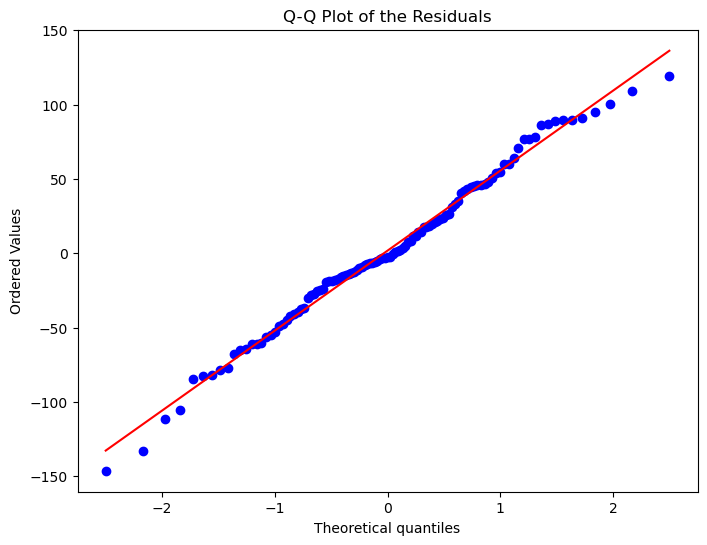

In [34]:
# Create a Q-Q plot to check the normality of the residuals

import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of the Residuals')
plt.show()

In [35]:
# Compute the mean of the residuals to check for systematic bias

residuals_mean = np.mean(residuals)
print(f"Mean residual: {residuals_mean:.4f}")

Mean residual: 1.8042


The **Q-Q plot** shows an approximately normal distribution of residuals for the central quantiles, but highlights deviations in the tails. This suggests that the linear model struggles to capture the variability of patients with very low or very high disease progression.

The **Breusch-Pagan test (p-value = 0.0310)** rejects the homoscedasticity hypothesis. The variance of the residuals is not constant, visually confirming the "funnel" effect observed in the residuals; the reliability of the predictions therefore tends to decrease for certain ranges of the physiological parameters.

The mean of the residuals (1.80) confirms the absence of a significant systematic bias at the global level, although it does indicate a marginal systematic underestimation that does not undermine the model's use as a preliminary screening tool.

In a medical context, these results say that the Ridge model predicts the "average" patient well, but is statistically aware of struggling with more complex or extreme clinical profiles.

The Ridge model's performance on the clean test set shows a slight improvement over the validation results (~53 vs ~56), providing encouraging feedback on the choices made. However, a small improvement in squared error can also be a sign of overfitting on the dataset, which prompts us to consider further investigation to rule out this possibility.

In [36]:
# Compare the R² value during training with the one after testing, and also add the baseline model's R² for a more complete comparison

y_train_pred = grid_search.best_estimator_.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

r2_test = r2_score(y_test, y_test_pred)

print(f"R² on Training Set: {r2_train:.4f}")
print(f"R² on Test Set: {r2_test:.4f}")
print(f"Baseline model R² on Test Set: {baseline_r2:.4f}")

R² on Training Set: 0.5138
R² on Test Set: 0.4903
Baseline model R² on Test Set: 0.4849


In [37]:
# Compute the MAE and compare it with RMSE

from sklearn.metrics import mean_absolute_error

test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Test Set MAE: {test_mae:.4f}")
print(f"Test Set RMSE: {test_rmse:.4f}")

Test Set MAE: 41.4924
Test Set RMSE: 53.0915


In [38]:
# Show the range of target values to better understand the error scale

print(f"Target range: {y.max() - y.min():.4f}")

# Compute the error percentages (MAE) relative to the target range and mean

percent_error_range = (test_mae / (y.max() - y.min())) * 100
percent_error_mean = (test_mae / y.mean()) * 100

print(f"Error percentage (MAE) relative to the target range: {percent_error_range:.2f}%")
print(f"Error percentage (MAE) relative to the target mean: {percent_error_mean:.2f}%")

Target range: 321.0000
Error percentage (MAE) relative to the target range: 12.93%
Error percentage (MAE) relative to the target mean: 27.27%


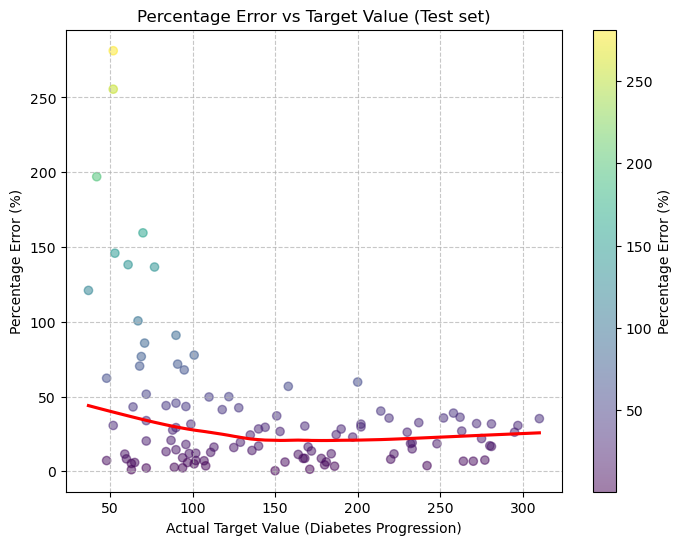

Test Set MAPE: 37.16%


In [39]:
# Show a chart of the percentage error versus the target value

plt.figure(figsize=(8, 6))
percent_errors = np.abs(y_test - y_test_pred) / y_test * 100 

# Scatter colored based on the magnitude of the percentage error
scatter = plt.scatter(y_test, percent_errors, c=percent_errors, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Percentage Error (%)') 

# Add a trend line to see whether the error grows/shrinks with the target
sns.regplot(x=y_test, y=percent_errors, scatter=False, color='red', lowess=True)

plt.title('Percentage Error vs Target Value (Test set)')
plt.xlabel('Actual Target Value (Diabetes Progression)')
plt.ylabel('Percentage Error (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Compute the mean percentage error (MAPE)

mape = np.mean(percent_errors)
print(f"Test Set MAPE: {mape:.2f}%")

These last comparisons give us a strong overall impression of the choice made.

The **R²** value on the training set and test set is almost the same (~51 vs ~49), which tells us that through heavy tuning of the alpha parameter, Ridge's generalization works quite well, and the risk of overfitting seems to have been avoided.

A **MAE** of ~41.5 points (substantially lower than the RMSE, further proof that the model penalizes extreme target values), while it might seem high, represents only 12.93% of the entire disease progression spectrum (range 321). This indicates that the model is able to correctly place a patient into the macro risk category (low, medium, high) with reasonable confidence.

The percentage error chart reveals that the model's precision increases proportionally with the severity of progression: for target values $< 100$, we see several points with errors above 100-200%. This happens because, mathematically, even a small absolute error (e.g., being off by 30 points on an actual value of 40) explodes in percentage terms. While the relative uncertainty is high for low target values, for patients with progression above 150 the error stabilizes, making the model a more reliable decision-support tool precisely in the most critical clinical cases.

Relative to the target's mean, the average error stands at 27.27%. While this variability prevents the model from being used as an absolute diagnostic tool, the informational gain over a naive baseline justifies its use as a screening system to identify early on the patients who need more aggressive therapeutic interventions.

### **Limitations of the Research**

The data analysis and the Machine Learning modeling shown in the notebook represent one possible strategy for tackling this particular dataset. While it is a technically sound and potentially effective path, it has a number of structural and procedural limitations that should be kept in mind.

The starting dataset, being part of a group of scikit-learn 'toy' datasets, is inherently not very representative of the reality of collecting and storing medical data — both because the samples considered are too few to be significant and to let an algorithm be deemed 'suitable' for this type of problem, and because the preprocessing choices made beforehand already steer toward a specific strategy and reduce the initial options.
Moreover, the research domain — the medical field — is known for noisy data, messy measurements, and the complexity of the indicators provided, which often vary and are not unambiguous, making it harder to capture the balance between linearity and non-linearity of the variables.

During the project, for the sake of simplicity, while not deviating from the task, it was deemed necessary to limit the number of possible choices to a single algorithm to train. Although the exploratory analysis and the subsequent ones steered the choice toward a Ridge model, the best regularization hyperparameter found via cross-validation (~26) clearly indicates that the relationships between the variables, and between the variables and the target, are perhaps too complex to be captured by a linear model.

Nonetheless, the decision-making process is entirely lacking in feature engineering, which could have reduced the algorithm's variance by a few points (e.g., by transforming the bmi variable into bmi^2).

Finally, the idea that an algorithm using ensemble techniques such as Random Forest or XGBoost might yield better results was not overlooked. However, sticking with the Ridge model was decided precisely because of the small size of the starting dataset, which could have confused more complex models such as those mentioned.

## **Final Conclusions**

* **Validation of the Methodological Path via Baseline**: Introducing a standard Linear Regression model as a baseline made it possible to quantify the effectiveness of the choices made. The numerical comparison shows that the optimized Ridge model outperforms the baseline (RMSE: 53.09 vs 53.37; $R^2$: 0.490 vs 0.485). While the numerical gap may seem small, it represents an optimal balance point between error and coefficient stability.

* **Effectiveness of Regularization against Multicollinearity**: The VIF (Variance Inflation Factor) analysis revealed high criticality (VIF > 50 for s1 and s2). Finding a high $\alpha$ value (~25.6) via Grid Search confirms that the model had to apply strong $L2$ penalization to stabilize the coefficients, resolving the structural instabilities detected in the baseline and ensuring that no redundant predictor incorrectly dominated the prediction.

* **Stability and Generalization**: The model shows excellent generalization capability, evidenced by the small gap (about 2%) between the training $R^2$ (0.51) and the test $R^2$ (0.49). This balance confirms that the hyperparameter tuning and the Repeated K-Fold Cross-Validation strategy effectively averted the risk of overfitting, typical of small datasets (n=442).

* **Diagnostic Analysis of Residuals and Heteroscedasticity**: The Breusch-Pagan test (p-value = 0.0310) formally rejected the homoscedasticity hypothesis. The variance of the residuals is not constant, indicating that the model's reliability varies with the physiological parameters. In addition, the Q-Q Plot highlighted deviations in the tails, signaling that the linear structure struggles to capture the most extreme or rare clinical profiles.

* **Relative Precision and MAE Evaluation**: The MAE of 41.49 represents about 12.93% of the target's total range. A key finding from the percentage error analysis is that the model's precision increases proportionally with the severity of progression (Target > 150), making it a more reliable decision-support tool precisely for patients in the most critical clinical conditions, where the relative error stabilizes.

* **Clinical Interpretation of the Predictors**: The results reflect the Mutual Information analyses: BMI and the s5 variable emerge as the main drivers. However, the penalization suffered by s6 (despite a relevant MI) suggests that Ridge regularization may have sacrificed part of the specific signal of some features to ensure the cohesion of the overall model in a context of high multicollinearity.

* **Final Summary and Limitations**: The project demonstrates that an approach based on preventive statistical diagnosis (VIF, MI) makes it possible to justify every algorithmic choice. There remains room for improvement related to the "toy" nature of the dataset and the absence of feature engineering (e.g., quadratic terms). Despite these limitations, the Ridge model stands out as an effective screening tool, capable of correctly placing patients into risk macro-categories with reasonable confidence.